In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
#data load
df = pd.read_csv("Dhaka_Air_Quality_Uncleaned.csv")
df

,datetime,location,PM2.5,PM10,NO2,SO2,CO,AQI
0,2022-02-22 20:00:00,Uttara,287.444850,288.126421,44.363359,17.625225,1.213907,235.54
1,2023-03-15 05:00:00,mirpur,67.400086,103.860560,47.244548,21.089036,1.068981,70.69
2,2023-03-27 23:00:00,Dhanmondi,107.864450,239.080587,32.344590,12.507405,1.282538,129.58
3,2019-05-08 13:00:00,UTTARA,143.069211,110.726542,27.446586,30.662250,0.679537,109.06
4,2019-03-04 10:00:00,Banani,152.862425,162.253481,39.783156,21.499916,1.011424,130.21
...,...,...,...,...,...,...,...,...
499995,2023-09-16 11:00:00,UTTARA,60.392094,163.773141,27.857502,9.530962,1.146322,82.65
499996,2022-04-04 03:00:00,mirpur,238.554132,90.014929,49.760880,21.072037,1.235408,152.37
499997,2022-07-22 09:00:00,UTTARA,124.417817,191.623676,31.201462,14.810195,2.554026,123.68
499998,2021-12-13 19:00:00,mirpur,269.243871,243.905213,28.050392,18.244269,0.808880,211.55


In [136]:
#Analyzing data
print(df.describe())
print()
print()
print(df.info())

               PM2.5           PM10            NO2            SO2  \
count  500000.000000  495000.000000  500000.000000  500000.000000   
mean      152.445337     179.921592      40.002729      20.005576   
std        73.367798      70.020697      14.999798       9.993907   
min      -302.783567    -154.826735     -30.905312     -26.973031   
25%       109.681479     132.758853      29.891557      13.271573   
50%       150.334778     180.090665      40.001415      20.007139   
75%       191.028805     226.986862      50.135265      26.748231   
max      1855.873770     500.740670     109.843638      65.357001   

                  CO            AQI  
count  500000.000000  495000.000000  
mean        1.500503     135.277363  
std         0.499730      42.266091  
min        -0.930469     -86.630000  
25%         1.164019     109.520000  
50%         1.500514     134.300000  
75%         1.837990     159.040000  
max         3.889763     997.560000  


<class 'pandas.core.frame.DataFram

In [137]:
#data cleaning
df["datetime"] = pd.to_datetime(df["datetime"],errors="coerce")
df["location"] = df["location"].astype(str)



df.drop_duplicates(subset={"datetime","location"},inplace=True)
df.replace("",np.nan,inplace=True)

In [161]:
#Feature Engineering
df["Month"] = df["datetime"].dt.month
df["Year"] = df["datetime"].dt.year
df["Date"] = df["datetime"].dt.date
df["Year-Month"] = df["datetime"].dt.to_period('M')
df["Day"] = df["datetime"].dt.weekday# [0 - Monday,1-Tuesday,...,6-Sunday]
converting_day_type = {
    0 : "Weekdays",
    1 : "Weekdays",
    2 : "Weekdays",
    3 : "Weekdays",
    4 : "Weekdays",
    5 : "Weekends",
    6 : "Weekends",
}
df["Day_type"] = df["Day"].map(converting_day_type)

In [139]:
#Monthly AQI TREND
monthly_avg_AQI = df.groupby(["Year-Month"])["AQI"].mean()

highest_aqi_month = monthly_avg_AQI.idxmax()
highest_aqi = monthly_avg_AQI.max()

print(f"Most Polluted Month : {highest_aqi_month}")
print(f"Highest Average AQI : {highest_aqi}")

Most Polluted Month : 2020-03
Highest Average AQI : 136.81134085541854


In [140]:
monthly_avg_AQI

Year-Month
2019-01    136.348679
2019-02    135.531218
2019-03    134.266019
2019-04    135.621105
2019-05    134.212155
              ...    
2024-08    134.959737
2024-09    134.964828
2024-10    134.335875
2024-11    134.978636
2024-12    134.525801
Freq: M, Name: AQI, Length: 72, dtype: float64

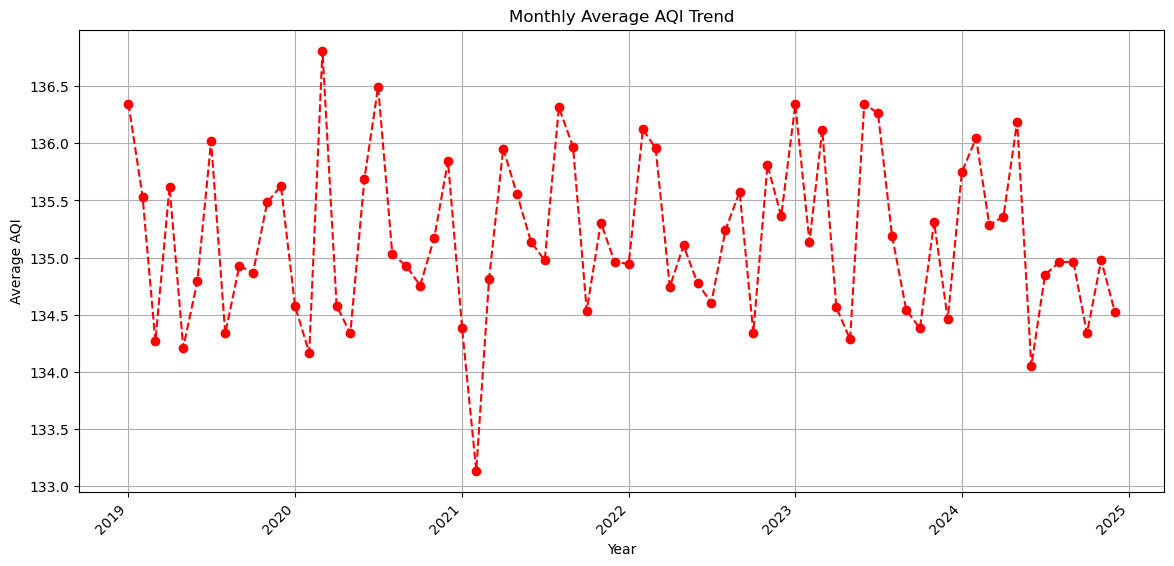

In [141]:
#ploting Monthly Average AQI
monthly_avg_AQI.index = monthly_avg_AQI.index.to_timestamp()

plt.figure(figsize=(14,6))
plt.plot(monthly_avg_AQI.index,monthly_avg_AQI.values,marker="o",linestyle="--",color="red")
plt.grid()
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.title("Monthly Average AQI Trend")

plt.xticks(rotation=45,ha="right")
plt.show()

In [142]:
#Seasonal AQI Trend
season = {
    12 : "Winter",
    1 : "Winter",
    2 : "Winter",
    3 : "Summer",
    4 : "Summer",
    5 : "Summer",
    6 : "Summer",
    7 : "Summer",
    8 : "Monsoon",
    9 : "Monsoon",
    10 : "Autumn",
    11 : "Autumn"
}

df["season"] = df["Month"].map(season)

season_wise_AQI = df.groupby("season")["AQI"].mean().reset_index().sort_values(by="AQI")

In [143]:
season_wise_AQI

,season,AQI
0,Autumn,134.931652
1,Monsoon,135.164425
3,Winter,135.188024
2,Summer,135.260256


In [144]:
#Is winter worse than summer?
summer_aqi = season_wise_AQI.loc[season_wise_AQI["season"]=="Summer","AQI"].values[0]
winter_aqi = season_wise_AQI.loc[season_wise_AQI["season"]=="Winter","AQI"].values[0]

if summer_aqi>winter_aqi :
    print("In Summer, City is more polluted than Winter.")
else : 
    print("In Winter, City is more polluted than Summer.")

In Summer, City is more polluted than Winter.


In [145]:
#yearwise AQI Trend
year_wise_AQI = df.groupby("Year")["AQI"].mean().reset_index().sort_values(by="Year")

max_AQI = year_wise_AQI["AQI"].max()
max_AQI_year = year_wise_AQI.loc[year_wise_AQI["AQI"].idxmax(),"Year"]

print(f"Highest AQI is {max_AQI} which occurs in year {max_AQI_year}")

Highest AQI is 135.2476078335807 which occurs in year 2023


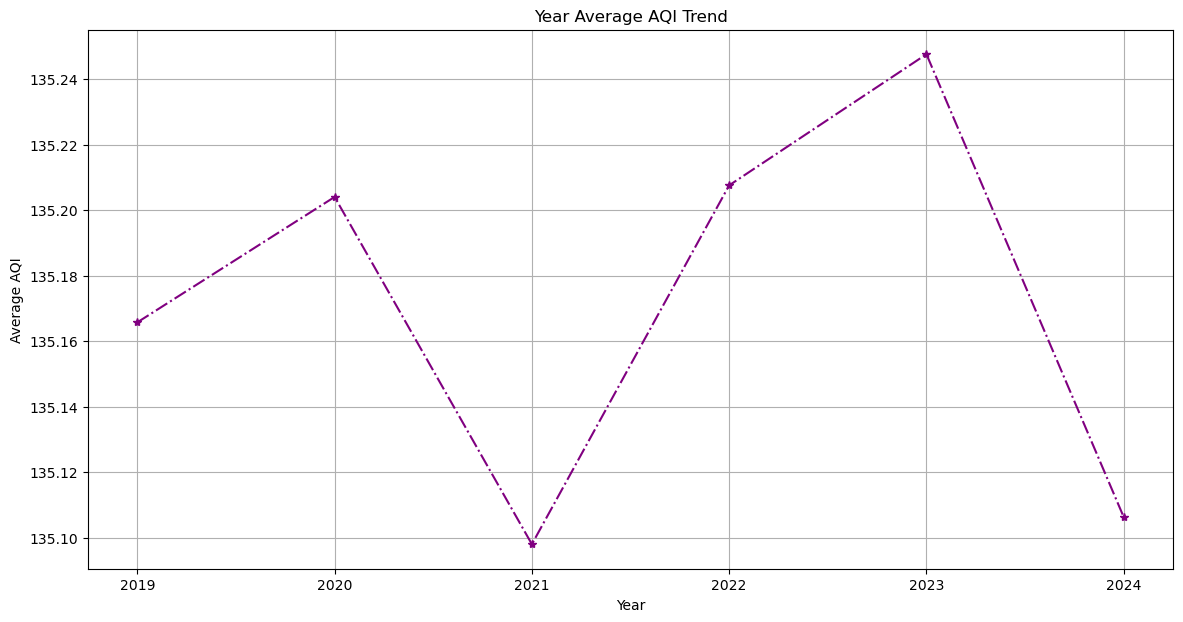

In [146]:
#Plotting yearwise AQI Trend

plt.figure(figsize=(14,7))
plt.plot(year_wise_AQI["Year"],year_wise_AQI["AQI"],color="purple",marker="*",
        linestyle="-.")
plt.title("Year Average AQI Trend")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid()

In [152]:
#Daytype and average AQI
avgAQI_daytype = df.groupby("Day_type")["AQI"].mean().reset_index()


#Are Weekdays more polluted than weekends
max_AQI = avgAQI_daytype["AQI"].max()
max_Daytype = avgAQI_daytype.loc[avgAQI_daytype["AQI"].idxmax(),"Day_type"]

print(f"{max_Daytype} often be more polluted with {max_AQI} AQI.")

Weekdays often be more polluted with 135.22180225947824 AQI.


In [153]:
avgAQI_daytype

,Day_type,AQI
0,Weekdays,135.221802
1,Weekends,135.045488


Friday is often be more polluted with 135.80102566753692 AQI.


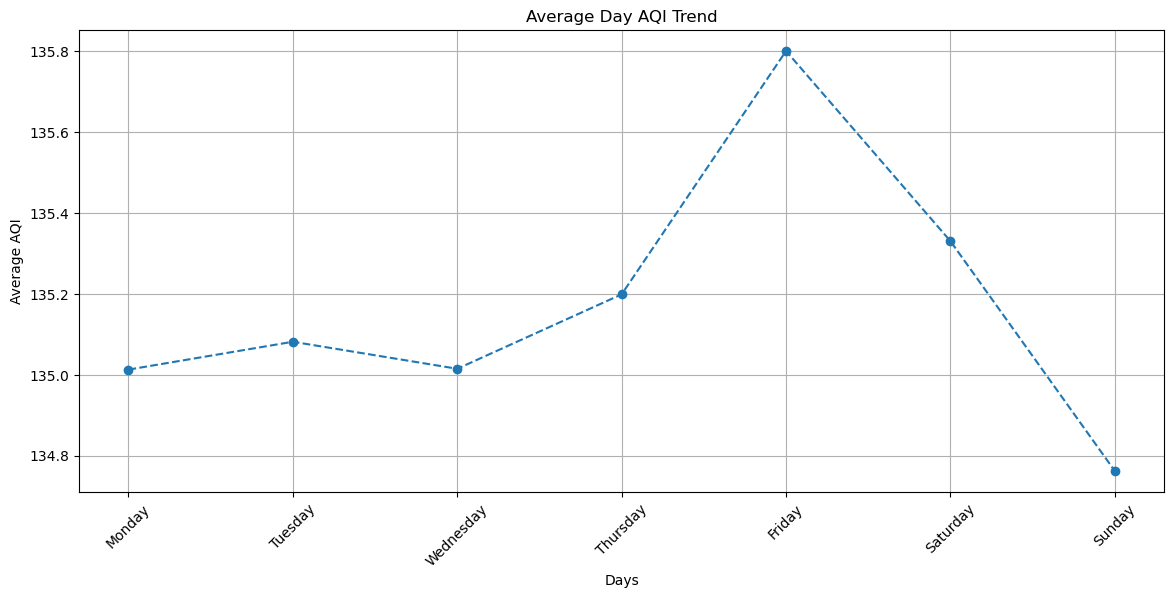

In [155]:
#Daywise and average AQI

avgAQI_Daywise = df.groupby("Day")["AQI"].mean().reset_index().sort_values(by="Day")

max_AQI = avgAQI_Daywise["AQI"].max()
max_Daywise = avgAQI_Daywise.loc[avgAQI_Daywise["AQI"].idxmax(),"Day"]

converting_day = {
    0 : "Monday",
    1 : "Tuesday",
    2 : "Wednesday",
    3 : "Thursday",
    4 : "Friday",
    5 : "Saturday",
    6 : "Sunday"
}
max_Daywise = converting_day[max_Daywise]

print(f"{max_Daywise} is often be more polluted with {max_AQI} AQI.")

#ploting
plt.figure(figsize=(14,6))
plt.plot(avgAQI_Daywise["Day"],avgAQI_Daywise["AQI"],marker="o",linestyle="--")
plt.xticks(avgAQI_Daywise["Day"],["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
          ,rotation=45)
plt.xlabel("Days")
plt.ylabel("Average AQI")
plt.title("Average Day AQI Trend")
plt.grid()

In [156]:
#which polutant contribute most on AQI,actually the more corr closed to AQI
#the more contribution increases
pollutants = ["PM2.5","PM10","NO2","SO2","CO"]

correlation = df[pollutants + ["AQI"]].corr()["AQI"].sort_values(ascending = False)
print(f"Correlation between AQI and Pollutants : ")
print(correlation)

Correlation between AQI and Pollutants : 
AQI      1.000000
PM2.5    0.866246
PM10     0.497104
NO2      0.032790
SO2      0.010638
CO       0.001329
Name: AQI, dtype: float64


In [157]:
#correlation between PM2.5 and AQI
#df[["PM2.5","AQI"]].corr()#returns matrix
corrPM2 = df["PM2.5"].corr(df["AQI"]).round(2)#return relation between them
print(f"Correlation between PM2.5 & AQI is {corrPM2}")

Correlation between PM2.5 & AQI is 0.87


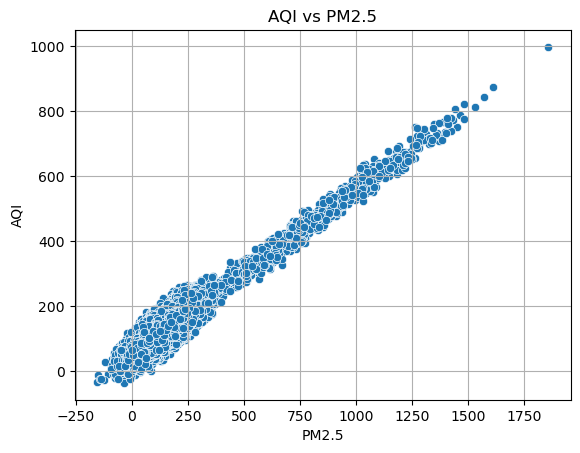

In [158]:
#plotting AQI vs PM2.5
sns.scatterplot(data=df,x="PM2.5",y="AQI")
plt.grid()
plt.title("AQI vs PM2.5")
plt.show()

In [159]:
#AQI Quality
condlist = [
    df["AQI"]<=50,
    df["AQI"]<=100,
    df["AQI"]<=150,
    df["AQI"]>150,
]

choicelist = ["Good","Moderate","Unhealthy for senisitive groups","Unhealthy"]

df["AQI_Quality"] = np.select(condlist,choicelist,"")

In [45]:
df

,datetime,location,PM2.5,PM10,NO2,SO2,CO,AQI,Month,Year,Year-Month,season,Day,Day_type,AQI_Quality
0,2022-02-22 20:00:00,Uttara,287.444850,288.126421,44.363359,17.625225,1.213907,235.54,2,2022,2022-02,Winter,1,Weekdays,Unhealthy
1,2023-03-15 05:00:00,mirpur,67.400086,103.860560,47.244548,21.089036,1.068981,70.69,3,2023,2023-03,Summer,2,Weekdays,Moderate
2,2023-03-27 23:00:00,Dhanmondi,107.864450,239.080587,32.344590,12.507405,1.282538,129.58,3,2023,2023-03,Summer,0,Weekdays,Unhealthy for senisitive groups
3,2019-05-08 13:00:00,UTTARA,143.069211,110.726542,27.446586,30.662250,0.679537,109.06,5,2019,2019-05,Summer,2,Weekdays,Unhealthy for senisitive groups
4,2019-03-04 10:00:00,Banani,152.862425,162.253481,39.783156,21.499916,1.011424,130.21,3,2019,2019-03,Summer,0,Weekdays,Unhealthy for senisitive groups
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499984,2023-09-19 04:00:00,Banani,75.343250,186.480377,60.833193,22.994596,1.308037,100.91,9,2023,2023-09,Monsoon,1,Weekdays,Unhealthy for senisitive groups
499988,2024-04-16 17:00:00,Dhanmondi,160.511260,166.078122,63.189112,23.766810,0.928751,137.63,4,2024,2024-04,Summer,1,Weekdays,Unhealthy for senisitive groups
499989,2024-04-24 16:00:00,Mirpur,107.981917,175.428451,52.475022,22.546923,1.447068,113.07,4,2024,2024-04,Summer,2,Weekdays,Unhealthy for senisitive groups
499992,2022-12-06 12:00:00,Uttara,172.806361,192.031324,60.883835,17.908061,1.616409,151.08,12,2022,2022-12,Winter,1,Weekdays,Unhealthy


In [164]:
#---------------High Risk Days Detection----------
#How many days per year were Unhealthy


unhealthydf = df.groupby("Date")["AQI"].mean().reset_index()
unhealthydf['year'] = pd.to_datetime(unhealthydf["Date"]).dt.year
condlist = [
    unhealthydf["AQI"]<=50,
    unhealthydf["AQI"]<=100,
    unhealthydf["AQI"]<=140,
    unhealthydf["AQI"]>140
]

choicelist = ["Good","Moderate","Unhealthy for senisitive groups","Unhealthy"]

unhealthydf["AQI_Quality_daywise"] = np.select(condlist,choicelist,"")
unhealthydf = unhealthydf[unhealthydf["AQI_Quality_daywise"]=="Unhealthy"]#Filtering
yearwise_unhealthy = unhealthydf.groupby("year")["AQI_Quality_daywise"].count().reset_index()
yearwise_unhealthy.columns = ["Year","Unhealthy_AQI_DAYS"]
yearwise_unhealthy

,Year,Unhealthy_AQI_DAYS
0,2019,37
1,2020,34
2,2021,42
3,2022,37
4,2023,45
5,2024,36


In [163]:
#----------Percentage of dangerous days------------

AQI_quality_count = df["AQI_Quality"].value_counts()
danger_day_percent = AQI_quality_count["Unhealthy"]*100/AQI_quality_count.values.sum()
print(f"Percentage of dangerous days {danger_day_percent.round(2)}%")

Percentage of dangerous days 32.95%
